In [ ]:
# ============================================================
# 0. INSTALL LIBRARIES
# ============================================================

!pip install pandas numpy matplotlib seaborn scikit-learn xgboost shap tensorflow openpyxl
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os # Moved import os to the top

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PowerTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import TransformedTargetRegressor

from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from xgboost import XGBRegressor

import shap
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv1D, Flatten, MaxPooling1D
from tensorflow.keras.callbacks import EarlyStopping
# ============================================================
# 3. MOUNT GOOGLE DRIVE
# ============================================================
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
# ============================================================
# 4. SET PATHS
# ============================================================

STACK_DIR = "/content/drive/MyDrive/PfPR_Predictors/"
PFPR_FILE = "/content/drive/MyDrive/PfPR/pfpr_data.csv"

YEARS = [2020, 2021, 2022, 2023, 2024]

FEATURE_NAMES = [
    "NDVI", "NDWI", "NDMI", "NDBI", "MNDWI",
    "LST", "Rainfall", "Elevation", "Slope", "DistWater"
]
import geopandas as gpd
import rasterio

# ============================================================
# 5. LOAD PfPR DATA
# ============================================================
pfpr_df = pd.read_csv(PFPR_FILE)

print(pfpr_df.head())
print(pfpr_df.columns)

pfpr_gdf = gpd.GeoDataFrame(
    pfpr_df,
    geometry=gpd.points_from_xy(pfpr_df["Longitude"], pfpr_df["Latitude"]),
    crs="EPSG:4326"
)
# ============================================================
# 6. EXTRACT PREDICTOR VALUES FROM 5 KM STACKS
# ============================================================
def extract_predictors_for_year(points_gdf, year, stack_dir, feature_names):
    stack_path = os.path.join(
        stack_dir,
        f"Karagwe_Predictor_Stack{year}.tif"
    )

    if not os.path.exists(stack_path):
        raise FileNotFoundError(f"Missing raster stack: {stack_path}")

    year_points = points_gdf[points_gdf["year"] == year].copy()

    if len(year_points) == 0:
        return pd.DataFrame()

    with rasterio.open(stack_path) as src:
        year_points = year_points.to_crs(src.crs)
        coords = [(geom.x, geom.y) for geom in year_points.geometry]
        sampled_values = list(src.sample(coords))

    predictors = pd.DataFrame(sampled_values, columns=feature_names)

    predictors["PfPR"] = year_points["PfPR"].values
    predictors["year"] = year
    predictors["longitude"] = year_points.geometry.x.values
    predictors["latitude"] = year_points.geometry.y.values

    if "ward" in year_points.columns:
        predictors["ward"] = year_points["ward"].values

    return predictors

all_data = []

# Rename the 'Year' column to 'year' and 'pfpr ' to 'PfPR' to match the function's expectations
pfpr_gdf = pfpr_gdf.rename(columns={'Year': 'year', 'pfpr ': 'PfPR'})

for year in YEARS:
    df_year = extract_predictors_for_year(
        pfpr_gdf,
        year,
        STACK_DIR,
        FEATURE_NAMES
    )
    all_data.append(df_year)

data = pd.concat(all_data, ignore_index=True)

print(data.head())
print(data.shape)


Mounted at /content/drive
   s/n  Latitude  Longitude  Year     pfpr 
0    1 -1.244686   31.18892  2020  8.513443
1    2 -1.244686   31.18892  2021  9.299484
2    3 -1.244686   31.18892  2022  9.087232
3    4 -1.244686   31.18892  2023  8.603277
4    5 -1.244686   31.18892  2024  8.219654
Index(['s/n', 'Latitude', 'Longitude', 'Year', 'pfpr '], dtype='object')
       NDVI      NDWI      NDMI      NDBI     MNDWI        LST     Rainfall  \
0  0.502644 -0.511904 -0.050696  0.050696 -0.548830  31.703306  1442.150024   
1  0.613448 -0.573868  0.088754 -0.088754 -0.511601  30.489561  1476.275391   
2  0.531998 -0.537170  0.021702 -0.021702 -0.521944  32.001888  1412.179810   
3  0.529743 -0.529859 -0.002044  0.002044 -0.531642  31.664438  1389.270508   
4  0.521180 -0.528747 -0.031863  0.031863 -0.551757  31.121084  1450.875366   

     Elevation     Slope    DistWater      PfPR  year  longitude  latitude  
0  1182.335449  1.650142  1838.831177  8.513443  2020  31.188920 -1.244686  
1  1165.

In [ ]:
import sklearn
print(sklearn.__version__)

1.6.1


In [ ]:
# ============================================================
# CLEAN DATASET: MISSING VALUES + DUPLICATES
# ============================================================

# ------------------------------------------------------------
# 1. Define features and target
# ------------------------------------------------------------

FEATURE_NAMES = [
    "NDVI",
    "NDWI",
    "NDMI",
    "NDBI",
    "MNDWI",
    "LST",
    "Rainfall",
    "Elevation",
    "Slope",
    "DistWater"
]

target = "PfPR"

# Remove extra spaces in column names
data.columns = data.columns.str.strip()

# ------------------------------------------------------------
# 2. Check original dataset size
# ------------------------------------------------------------

print("Original dataset shape:", data.shape)

# ------------------------------------------------------------
# 3. Replace infinite values with missing values
# ------------------------------------------------------------

data = data.replace([np.inf, -np.inf], np.nan)

# ------------------------------------------------------------
# 4. Check missing values before cleaning
# ------------------------------------------------------------

print("\nMissing values before cleaning:")
print(data[FEATURE_NAMES + [target]].isnull().sum())

# ------------------------------------------------------------
# 5. Remove rows with missing target value
# ------------------------------------------------------------

data = data.dropna(subset=[target])

# ------------------------------------------------------------
# 6. Remove rows where all predictors are missing
# ------------------------------------------------------------

data = data.dropna(subset=FEATURE_NAMES, how="all")

# ------------------------------------------------------------
# 7. Fill missing predictor values using median
# ------------------------------------------------------------

for col in FEATURE_NAMES:
    data[col] = data[col].fillna(data[col].median())

# ------------------------------------------------------------
# 8. Remove exact duplicate rows
# ------------------------------------------------------------

duplicate_columns = [
    "longitude",
    "latitude",
    "year",
    "NDVI",
    "NDWI",
    "NDMI",
    "NDBI",
    "MNDWI",
    "LST",
    "Rainfall",
    "Elevation",
    "Slope",
    "DistWater",
    "PfPR"
]

duplicate_columns = [col for col in duplicate_columns if col in data.columns]

duplicated_rows = data.duplicated(
    subset=duplicate_columns,
    keep=False
).sum()

print("\nTotal duplicated rows found:", duplicated_rows)

data_clean = data.drop_duplicates(
    subset=duplicate_columns
).reset_index(drop=True)

# ------------------------------------------------------------
# 9. Check missing values after cleaning
# ------------------------------------------------------------

print("\nMissing values after cleaning:")
print(data_clean[FEATURE_NAMES + [target]].isnull().sum())

# ------------------------------------------------------------
# 10. Display cleaned dataset summary
# ------------------------------------------------------------

print("\nCleaned dataset shape:", data_clean.shape)
print("\nDescriptive statistics:")
print(data_clean[FEATURE_NAMES + [target]].describe())

# ------------------------------------------------------------
# 11. Create X and y after cleaning
# ------------------------------------------------------------

X = data_clean[FEATURE_NAMES].copy()
y = data_clean[target].copy()

print("\nX shape:", X.shape)
print("y shape:", y.shape)

# ------------------------------------------------------------
# 12. Save cleaned dataset
# ------------------------------------------------------------

data_clean.to_csv(
    "/content/pfpr_cleaned_dataset.csv",
    index=False
)

print("\nCleaned dataset saved as:")
print("/content/pfpr_cleaned_dataset.csv")
# ============================================================
# USE CLEANED DATASET FOR SUBSEQUENT ANALYSIS
# ============================================================

data = data_clean.copy()

print("\nDataset used for subsequent analyses:")
print(data.shape)

# Create predictor and target variables
X = data[FEATURE_NAMES].copy()
y = data[target].copy()

print("\nPredictor matrix (X):", X.shape)
print("Target variable (y):", y.shape)

Original dataset shape: (3165, 14)

Missing values before cleaning:
NDVI         0
NDWI         0
NDMI         0
NDBI         0
MNDWI        0
LST          0
Rainfall     0
Elevation    0
Slope        0
DistWater    0
PfPR         0
dtype: int64

Total duplicated rows found: 2550

Missing values after cleaning:
NDVI         0
NDWI         0
NDMI         0
NDBI         0
MNDWI        0
LST          0
Rainfall     0
Elevation    0
Slope        0
DistWater    0
PfPR         0
dtype: int64

Cleaned dataset shape: (1465, 14)

Descriptive statistics:
              NDVI         NDWI         NDMI         NDBI        MNDWI  \
count  1465.000000  1465.000000  1465.000000  1465.000000  1465.000000   
mean      0.476494    -0.495862     0.006320    -0.006320    -0.493785   
std       0.084989     0.089083     0.061050     0.061050     0.100628   
min       0.106451    -0.642565    -0.159141    -0.317561    -0.591571   
25%       0.439601    -0.550879    -0.027887    -0.034114    -0.558802   
50%  

Plotting histograms...


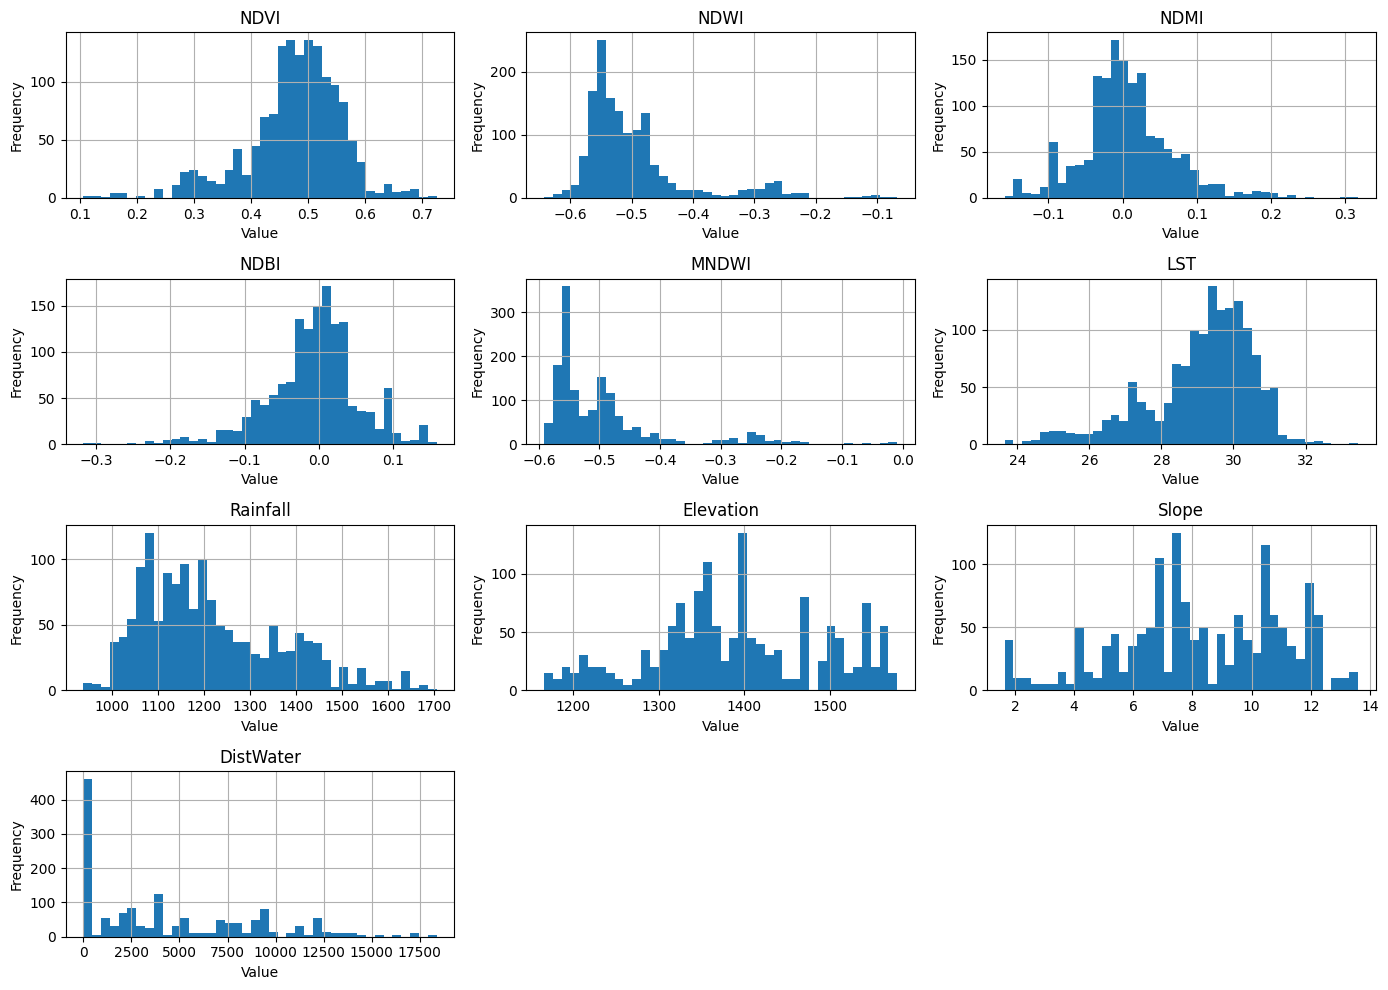

In [ ]:
print("Plotting histograms...")
axes = data[FEATURE_NAMES].hist(bins=40, figsize=(14,10))
# Add axis labels to each subplot
for ax in axes.flatten():
    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

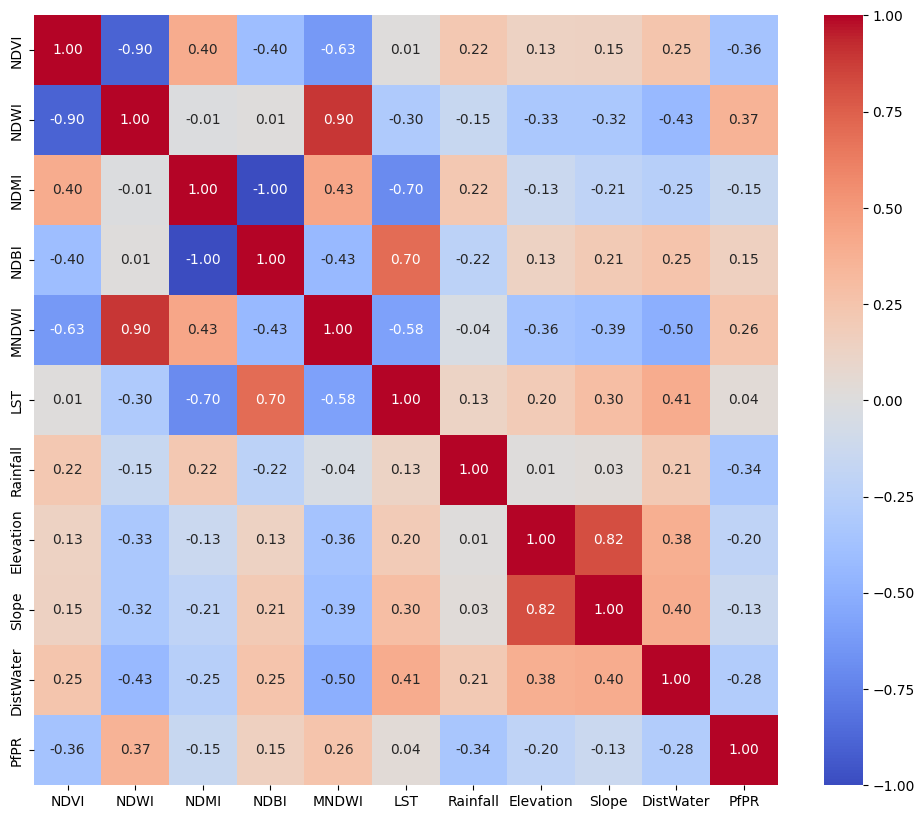

In [ ]:
corr = data[FEATURE_NAMES + ["PfPR"]].corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=True, fmt=".2f")
plt.show()

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# ============================================================
# 10. FEATURE-SPECIFIC PREPROCESSING
# ============================================================
# DistWater: minimum aggregation was already done in GEE.
# Here we apply log1p transformation, then MinMax scaling.

data["DistWater"] = np.log1p(data["DistWater"])

spectral_features = ["NDVI", "NDWI", "NDMI","NDBI", "MNDWI"]
standard_features = ["LST", "Rainfall", "Elevation", "Slope"]
distance_features = ["DistWater"]

final_features = spectral_features + standard_features + distance_features

X = data[final_features]
y = data["PfPR"]
preprocessor = ColumnTransformer(
    transformers=[
        ("spectral_minmax", MinMaxScaler(), spectral_features),
        ("standard_vars", StandardScaler(), standard_features),
        ("distance_minmax", MinMaxScaler(), distance_features)
    ]
)

processed_feature_names = spectral_features + standard_features + distance_features

All features: ['NDVI', 'NDWI', 'NDMI', 'NDBI', 'MNDWI', 'LST', 'Rainfall', 'Elevation', 'Slope', 'DistWater']
Removed highly correlated features: ['NDVI', 'MNDWI', 'Slope', 'NDBI']
Reduced features: ['NDWI', 'NDMI', 'LST', 'Rainfall', 'Elevation', 'DistWater']

FEATURE SET: All Variables
Training samples: (1172, 10)
Testing samples: (293, 10)

Training Random Forest using All Variables...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters:
{'model__n_estimators': 700, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 0.5, 'model__max_depth': 20}
{'Feature_Set': 'All Variables', 'Model': 'Random Forest', 'R2': 0.86255929996443, 'RMSE': np.float64(0.8047580249128863), 'MAE': 0.5730868882772162}


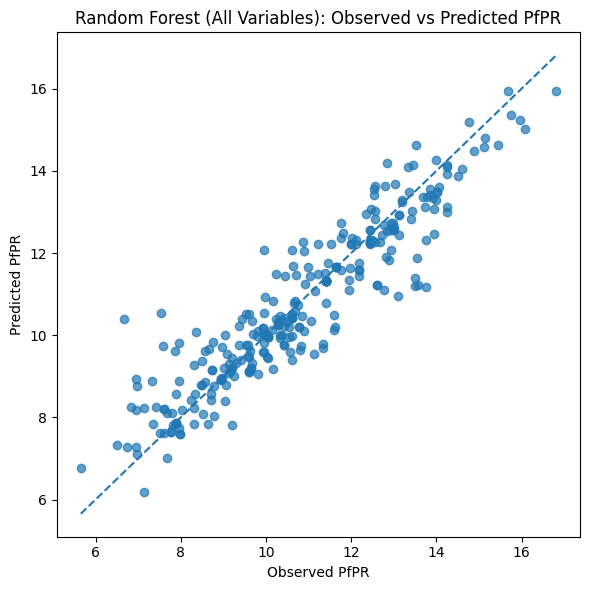


Training XGBoost using All Variables...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters:
{'model__subsample': 1.0, 'model__reg_lambda': 5, 'model__reg_alpha': 1, 'model__n_estimators': 700, 'model__max_depth': 5, 'model__learning_rate': 0.1, 'model__colsample_bytree': 0.7}
{'Feature_Set': 'All Variables', 'Model': 'XGBoost', 'R2': 0.8873874694544612, 'RMSE': np.float64(0.7284520933981247), 'MAE': 0.5222226439261496}


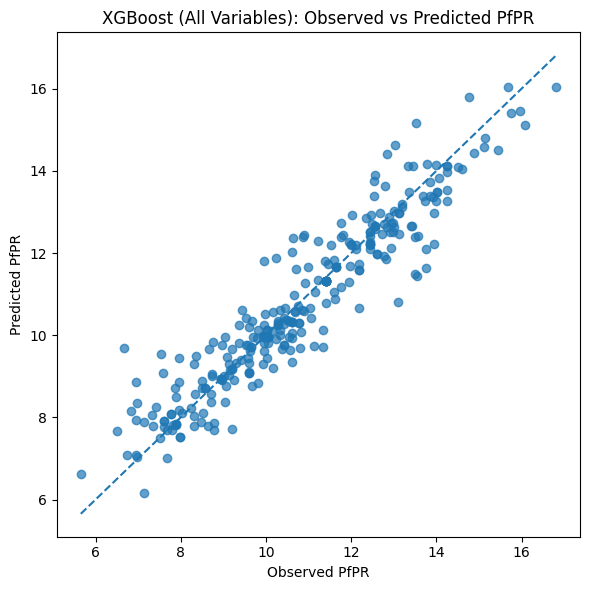


Training SVR using All Variables...
Fitting 5 folds for each of 18 candidates, totalling 90 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 18 is smaller than n_iter=20. Running 18 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best parameters:
{'model__kernel': 'rbf', 'model__gamma': 'auto', 'model__epsilon': 0.2, 'model__C': 100}
{'Feature_Set': 'All Variables', 'Model': 'SVR', 'R2': 0.7736863618227281, 'RMSE': np.float64(1.0326734227219077), 'MAE': 0.7432898130111009}


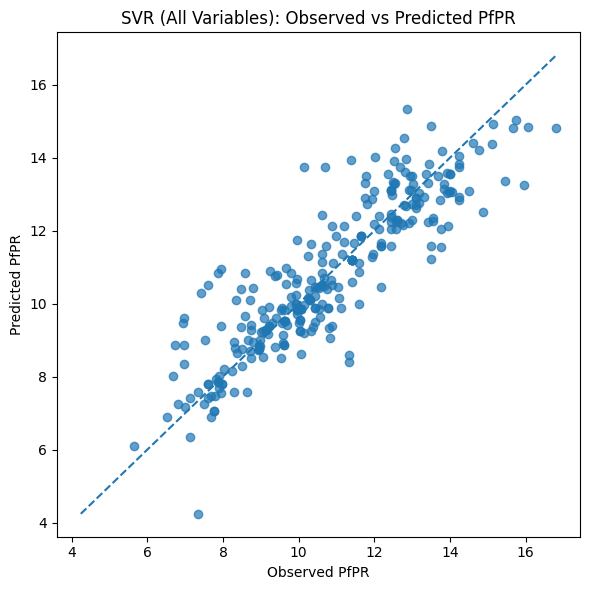


Training MLP using All Variables...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters:
{'model__learning_rate_init': 0.01, 'model__hidden_layer_sizes': (128, 64), 'model__alpha': 0.001, 'model__activation': 'tanh'}
{'Feature_Set': 'All Variables', 'Model': 'MLP', 'R2': 0.7647588842638118, 'RMSE': np.float64(1.0528445469732157), 'MAE': 0.751580905419332}


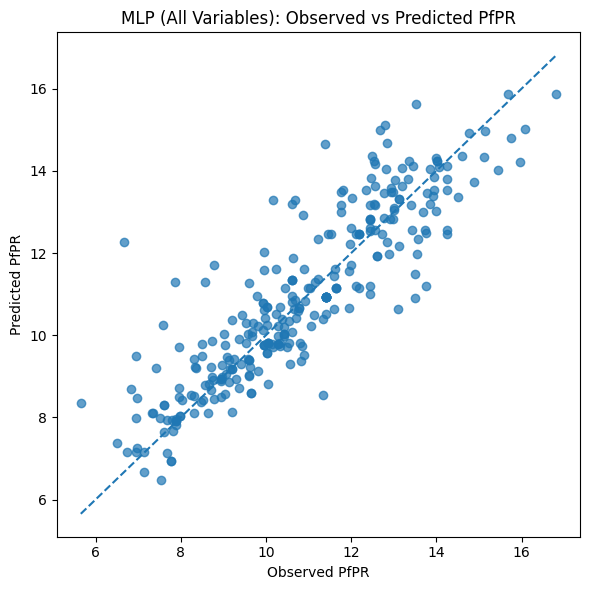


FEATURE SET: Reduced Variables
Training samples: (1172, 6)
Testing samples: (293, 6)

Training Random Forest using Reduced Variables...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters:
{'model__n_estimators': 700, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 0.5, 'model__max_depth': 20}
{'Feature_Set': 'Reduced Variables', 'Model': 'Random Forest', 'R2': 0.8473225136545852, 'RMSE': np.float64(0.8481938856122856), 'MAE': 0.5926489814897958}


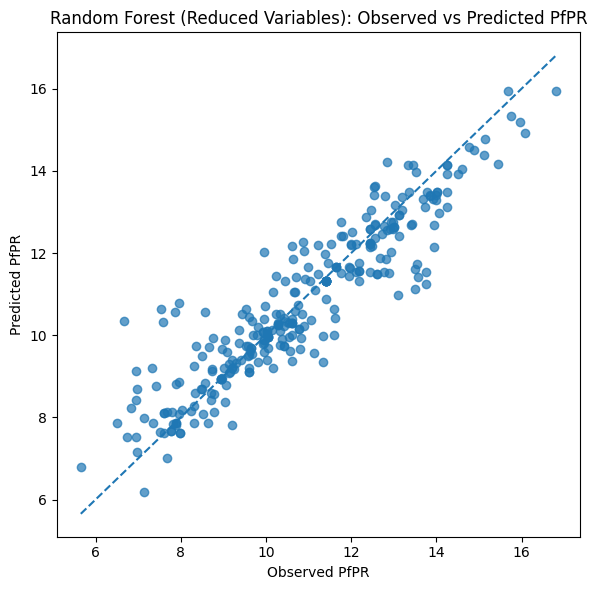


Training XGBoost using Reduced Variables...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters:
{'model__subsample': 1.0, 'model__reg_lambda': 5, 'model__reg_alpha': 1, 'model__n_estimators': 700, 'model__max_depth': 5, 'model__learning_rate': 0.1, 'model__colsample_bytree': 0.7}
{'Feature_Set': 'Reduced Variables', 'Model': 'XGBoost', 'R2': 0.87875446765053, 'RMSE': np.float64(0.7558585137373546), 'MAE': 0.5394676076587097}


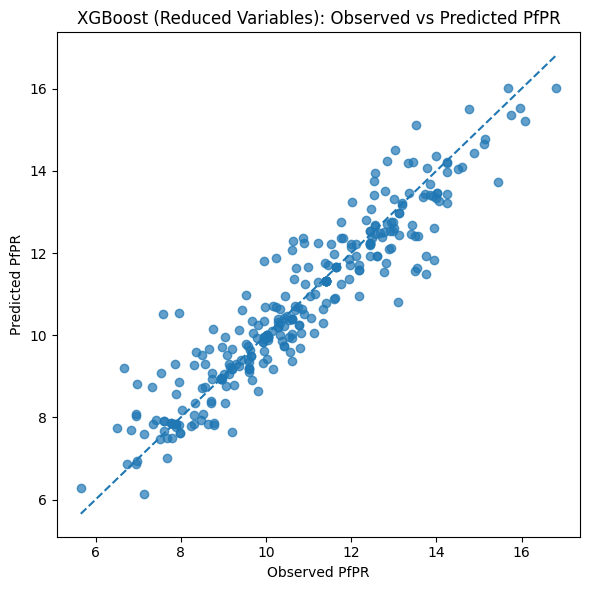


Training SVR using Reduced Variables...
Fitting 5 folds for each of 18 candidates, totalling 90 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 18 is smaller than n_iter=20. Running 18 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best parameters:
{'model__kernel': 'rbf', 'model__gamma': 'auto', 'model__epsilon': 0.2, 'model__C': 100}
{'Feature_Set': 'Reduced Variables', 'Model': 'SVR', 'R2': 0.756909236012083, 'RMSE': np.float64(1.0702663377132766), 'MAE': 0.7838575257401194}


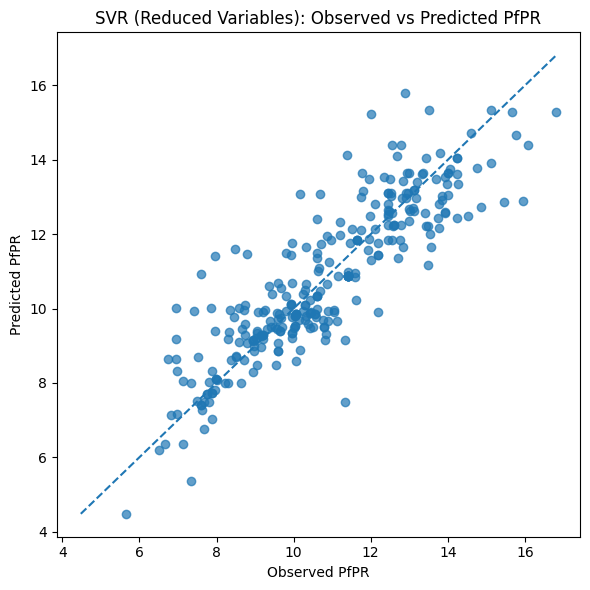


Training MLP using Reduced Variables...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters:
{'model__learning_rate_init': 0.01, 'model__hidden_layer_sizes': (64, 32), 'model__alpha': 0.001, 'model__activation': 'tanh'}
{'Feature_Set': 'Reduced Variables', 'Model': 'MLP', 'R2': 0.8085095448321948, 'RMSE': np.float64(0.949907250439145), 'MAE': 0.709646411160543}


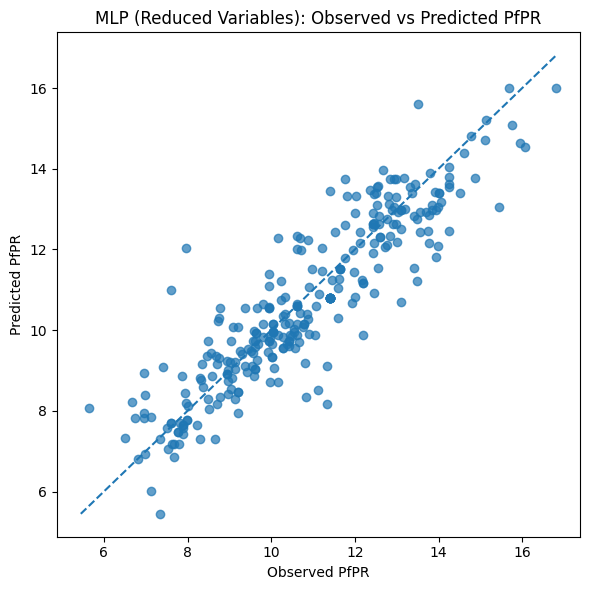


Final Model Comparison:
         Feature_Set          Model        R2      RMSE       MAE
0      All Variables        XGBoost  0.887387  0.728452  0.522223
1  Reduced Variables        XGBoost  0.878754  0.755859  0.539468
2      All Variables  Random Forest  0.862559  0.804758  0.573087
3  Reduced Variables  Random Forest  0.847323  0.848194  0.592649
4  Reduced Variables            MLP  0.808510  0.949907  0.709646
5      All Variables            SVR  0.773686  1.032673  0.743290
6      All Variables            MLP  0.764759  1.052845  0.751581
7  Reduced Variables            SVR  0.756909  1.070266  0.783858

Results saved as:
/content/model_comparison_all_vs_reduced_features.csv

Best model overall:
Feature_Set    All Variables
Model                XGBoost
R2                  0.887387
RMSE                0.728452
MAE                 0.522223
Name: 0, dtype: object


In [ ]:
# ============================================================
# COMPARE MODEL PERFORMANCE: ALL VARIABLES VS REDUCED VARIABLES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


# ============================================================
# 1. DEFINE FEATURES AND TARGET
# ============================================================

features = [
    "NDVI", "NDWI", "NDMI", "NDBI", "MNDWI",
    "LST", "Rainfall", "Elevation", "Slope", "DistWater"
]

target = "PfPR"


# ============================================================
# 2. FUNCTION TO REMOVE HIGHLY CORRELATED FEATURES
# ============================================================

def remove_highly_correlated_features(df, features, target, threshold=0.7):
    corr_matrix = df[features].corr().abs()
    target_corr = df[features + [target]].corr()[target].abs()

    remove_features = set()

    for i in range(len(features)):
        for j in range(i + 1, len(features)):
            f1 = features[i]
            f2 = features[j]

            if corr_matrix.loc[f1, f2] > threshold:
                # Keep the variable more correlated with PfPR
                if target_corr[f1] >= target_corr[f2]:
                    remove_features.add(f2)
                else:
                    remove_features.add(f1)

    selected_features = [
        f for f in features if f not in remove_features
    ]

    return selected_features, list(remove_features)


reduced_features, removed_features = remove_highly_correlated_features(
    data,
    features,
    target,
    threshold=0.7
)

print("All features:", features)
print("Removed highly correlated features:", removed_features)
print("Reduced features:", reduced_features)


# ============================================================
# 3. EVALUATION FUNCTIONS
# ============================================================

def evaluate_model(model_name, feature_set_name, model, X_test, y_test):
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    results = {
        "Feature_Set": feature_set_name,
        "Model": model_name,
        "R2": r2,
        "RMSE": rmse,
        "MAE": mae
    }

    print(results)

    return results, y_pred


def plot_observed_vs_predicted(y_true, y_pred, title):
    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, alpha=0.7)

    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())

    plt.plot(
        [min_val, max_val],
        [min_val, max_val],
        linestyle="--"
    )

    plt.xlabel("Observed PfPR")
    plt.ylabel("Predicted PfPR")
    plt.title(title)
    plt.tight_layout()
    plt.show()


# ============================================================
# 4. MODEL PARAMETER GRIDS
# ============================================================

rf_params = {
    "model__n_estimators": [300, 500, 700],
    "model__max_depth": [10, 20, 30, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", 0.5]
}

xgb_params = {
    "model__n_estimators": [300, 500, 700],
    "model__max_depth": [3, 5, 7, 10],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__subsample": [0.7, 0.8, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 1.0],
    "model__reg_lambda": [1, 5, 10],
    "model__reg_alpha": [0, 0.1, 1]
}

svr_params = {
    "model__C": [1, 10, 100],
    "model__gamma": ["scale", "auto"],
    "model__epsilon": [0.01, 0.1, 0.2],
    "model__kernel": ["rbf"]
}

mlp_params = {
    "model__hidden_layer_sizes": [(64,), (128,), (64, 32), (128, 64)],
    "model__activation": ["relu", "tanh"],
    "model__alpha": [0.0001, 0.001, 0.01],
    "model__learning_rate_init": [0.001, 0.01]
}


# ============================================================
# 5. FUNCTION TO TRAIN MODELS FOR A GIVEN FEATURE SET
# ============================================================

def run_models_for_feature_set(
    data,
    selected_features,
    target,
    feature_set_name
):
    X = data[selected_features].copy()
    y = data[target].copy()

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42
    )

    print("\n============================================")
    print(f"FEATURE SET: {feature_set_name}")
    print("Training samples:", X_train.shape)
    print("Testing samples:", X_test.shape)
    print("============================================")

    # Preprocessor
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), selected_features)
        ],
        remainder="drop"
    )

    models = {
        "Random Forest": (
            Pipeline([
                ("preprocessor", preprocessor),
                ("imputer", SimpleImputer(strategy="median")),
                ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
            ]),
            rf_params
        ),

        "XGBoost": (
            Pipeline([
                ("preprocessor", preprocessor),
                ("imputer", SimpleImputer(strategy="median")),
                ("model", XGBRegressor(
                    objective="reg:squarederror",
                    random_state=42,
                    n_jobs=-1
                ))
            ]),
            xgb_params
        ),

        "SVR": (
            Pipeline([
                ("preprocessor", preprocessor),
                ("imputer", SimpleImputer(strategy="median")),
                ("model", SVR())
            ]),
            svr_params
        ),

        "MLP": (
            Pipeline([
                ("preprocessor", preprocessor),
                ("imputer", SimpleImputer(strategy="median")),
                ("model", MLPRegressor(
                    random_state=42,
                    max_iter=1000
                ))
            ]),
            mlp_params
        )
    }

    results_list = []
    predictions = {}
    best_estimators = {}

    for model_name, (pipeline, params) in models.items():
        print(f"\nTraining {model_name} using {feature_set_name}...")

        search = RandomizedSearchCV(
            pipeline,
            params,
            n_iter=20,
            cv=5,
            scoring="r2",
            random_state=42,
            n_jobs=-1,
            verbose=1
        )

        search.fit(X_train, y_train)

        print("Best parameters:")
        print(search.best_params_)

        results, y_pred = evaluate_model(
            model_name,
            feature_set_name,
            search.best_estimator_,
            X_test,
            y_test
        )

        results_list.append(results)
        predictions[model_name] = (y_test, y_pred)
        best_estimators[model_name] = search.best_estimator_

        plot_observed_vs_predicted(
            y_test,
            y_pred,
            f"{model_name} ({feature_set_name}): Observed vs Predicted PfPR"
        )

    return results_list, predictions, best_estimators


# ============================================================
# 6. RUN MODELS USING ALL VARIABLES
# ============================================================

all_results, all_predictions, all_estimators = run_models_for_feature_set(
    data=data,
    selected_features=features,
    target=target,
    feature_set_name="All Variables"
)


# ============================================================
# 7. RUN MODELS USING REDUCED VARIABLES
# ============================================================

reduced_results, reduced_predictions, reduced_estimators = run_models_for_feature_set(
    data=data,
    selected_features=reduced_features,
    target=target,
    feature_set_name="Reduced Variables"
)


# ============================================================
# 8. COMBINE AND DISPLAY RESULTS
# ============================================================

results_df = pd.DataFrame(all_results + reduced_results)

results_df = results_df.sort_values(
    by=["R2"],
    ascending=False
).reset_index(drop=True)

print("\nFinal Model Comparison:")
print(results_df)


# ============================================================
# 9. SAVE RESULTS
# ============================================================

results_df.to_csv(
    "/content/model_comparison_all_vs_reduced_features.csv",
    index=False
)

print("\nResults saved as:")
print("/content/model_comparison_all_vs_reduced_features.csv")


# ============================================================
# 10. IDENTIFY BEST MODEL
# ============================================================

best_result = results_df.iloc[0]

print("\nBest model overall:")
print(best_result)

In [ ]:
# ============================================================
# SAVE RANDOM FOREST MODEL (REDUCED FEATURES)
# ============================================================

import os
import json
import joblib

# Folder to save deployment files
save_dir = "/content/drive/MyDrive/PfPR_RF_Reduced_Model"

os.makedirs(save_dir, exist_ok=True)

# Save the trained pipeline
joblib.dump(
    reduced_estimators["Random Forest"],
    f"{save_dir}/best_rf_reduced_model.joblib"
)

print("Random Forest model saved.")
# ============================================================
# SAVE RETAINED FEATURES
# ============================================================

feature_metadata = {
    "feature_names": reduced_features,
    "target": "PfPR",
    "target_units": "%",
    "model": "Random Forest",
    "feature_set": "Reduced Variables",
    "number_of_features": len(reduced_features),
    "removed_features": removed_features
}

with open(
    f"{save_dir}/features.json",
    "w"
) as f:
    json.dump(feature_metadata, f, indent=4)

print("Feature names saved.")
# ============================================================
# SAVE MODEL INFORMATION
# ============================================================

model_info = {
    "model_name": "Random Forest",
    "feature_set": "Reduced Variables",
    "target": "PfPR",
    "target_units": "%",
    "prediction_scale": "0-100 %",
    "training_dataset": "Karagwe District",
    "years": "2020-2024",
    "removed_highly_correlated_variables": removed_features,
    "retained_variables": reduced_features
}

with open(
    f"{save_dir}/model_info.json",
    "w"
) as f:
    json.dump(model_info, f, indent=4)

print("Model information saved.")
# ============================================================
# VERIFY SAVED FILES
# ============================================================

print("Saved files:")

for file in os.listdir(save_dir):
    print(file)

Random Forest model saved.
Feature names saved.
Model information saved.
Saved files:
best_rf_reduced_model.joblib
features.json
model_info.json


     Feature  Importance  Relative Importance (%)
1       NDWI    0.253714                25.371352
4      MNDWI    0.173378                17.337849
6   Rainfall    0.113316                11.331560
0       NDVI    0.082629                 8.262888
7  Elevation    0.071072                 7.107151
3       NDBI    0.067904                 6.790356
2       NDMI    0.067342                 6.734247
8      Slope    0.065740                 6.573992
5        LST    0.063611                 6.361051
9  DistWater    0.041296                 4.129553


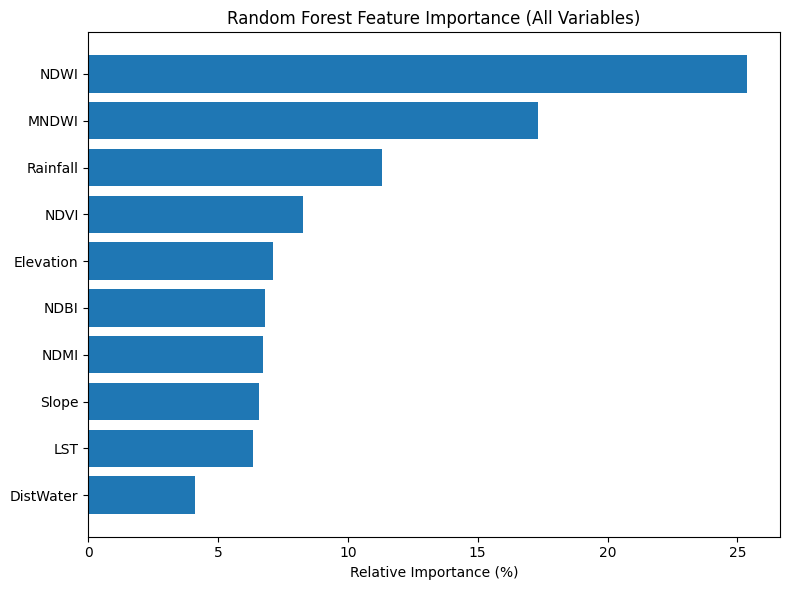

     Feature  Importance  Relative Importance (%)
0       NDWI    0.376332                37.633176
3   Rainfall    0.181546                18.154632
4  Elevation    0.133409                13.340881
1       NDMI    0.132734                13.273435
2        LST    0.097435                 9.743494
5  DistWater    0.078544                 7.854382


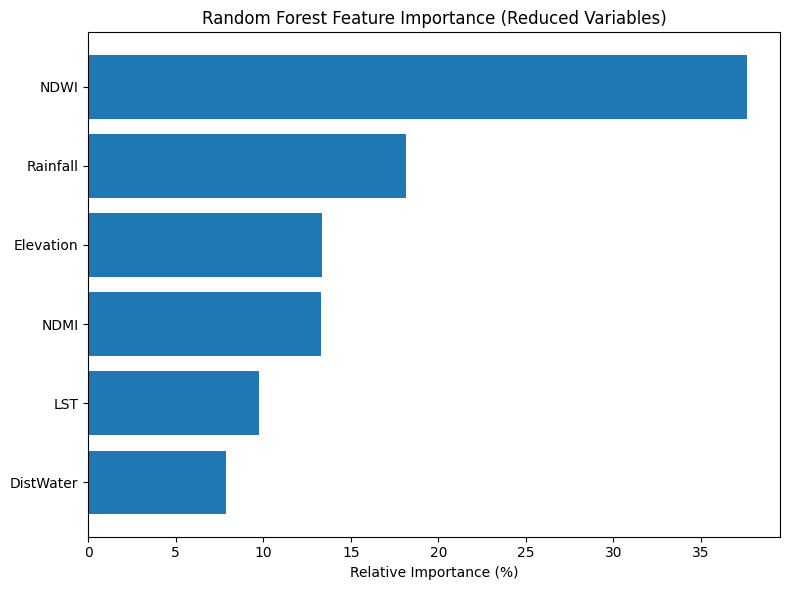

In [ ]:
# ============================================================
# RANDOM FOREST FEATURE IMPORTANCE (ALL VARIABLES)
# ============================================================

rf_all = all_estimators["Random Forest"]

rf_model = rf_all.named_steps["model"]

importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
})

importance["Relative Importance (%)"] = (
    importance["Importance"] /
    importance["Importance"].sum()
) * 100

importance = importance.sort_values(
    "Relative Importance (%)",
    ascending=False
)

print(importance)

plt.figure(figsize=(8,6))

plt.barh(
    importance["Feature"],
    importance["Relative Importance (%)"]
)

plt.xlabel("Relative Importance (%)")
plt.title("Random Forest Feature Importance (All Variables)")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()
# ============================================================
# RANDOM FOREST FEATURE IMPORTANCE (REDUCED VARIABLES)
# ============================================================

rf_red = reduced_estimators["Random Forest"]

rf_model = rf_red.named_steps["model"]

importance_red = pd.DataFrame({
    "Feature": reduced_features,
    "Importance": rf_model.feature_importances_
})

importance_red["Relative Importance (%)"] = (
    importance_red["Importance"] /
    importance_red["Importance"].sum()
) * 100

importance_red = importance_red.sort_values(
    "Relative Importance (%)",
    ascending=False
)

print(importance_red)

plt.figure(figsize=(8,6))

plt.barh(
    importance_red["Feature"],
    importance_red["Relative Importance (%)"]
)

plt.xlabel("Relative Importance (%)")
plt.title("Random Forest Feature Importance (Reduced Variables)")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

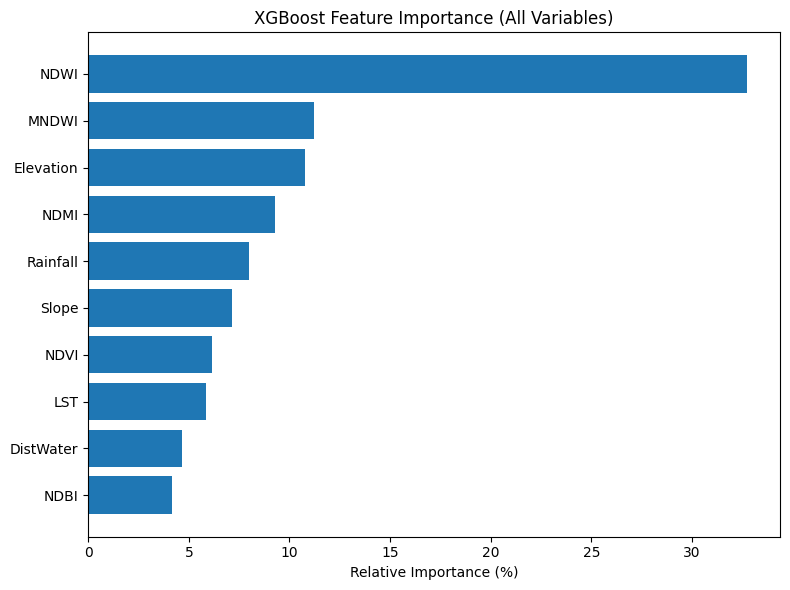

In [ ]:
# ============================================================
# XGBOOST FEATURE IMPORTANCE (ALL VARIABLES)
# ============================================================

xgb_all = all_estimators["XGBoost"]

xgb_model = xgb_all.named_steps["model"]

importance = pd.DataFrame({

    "Feature":features,

    "Importance":xgb_model.feature_importances_

})

importance["Relative Importance (%)"] = (

    importance["Importance"]/

    importance["Importance"].sum()

)*100

importance = importance.sort_values(

    "Relative Importance (%)",

    ascending=False

)

plt.figure(figsize=(8,6))

plt.barh(

    importance["Feature"],

    importance["Relative Importance (%)"]

)

plt.xlabel("Relative Importance (%)")

plt.title("XGBoost Feature Importance (All Variables)")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()
xgb_red = reduced_estimators["XGBoost"]

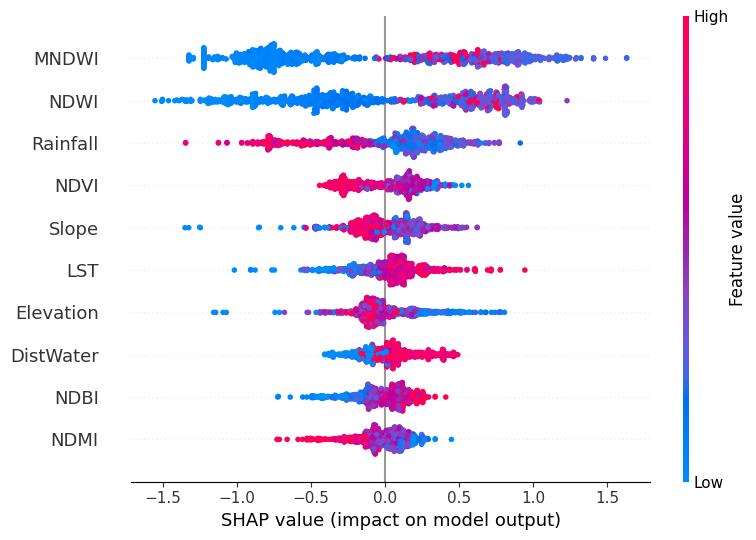

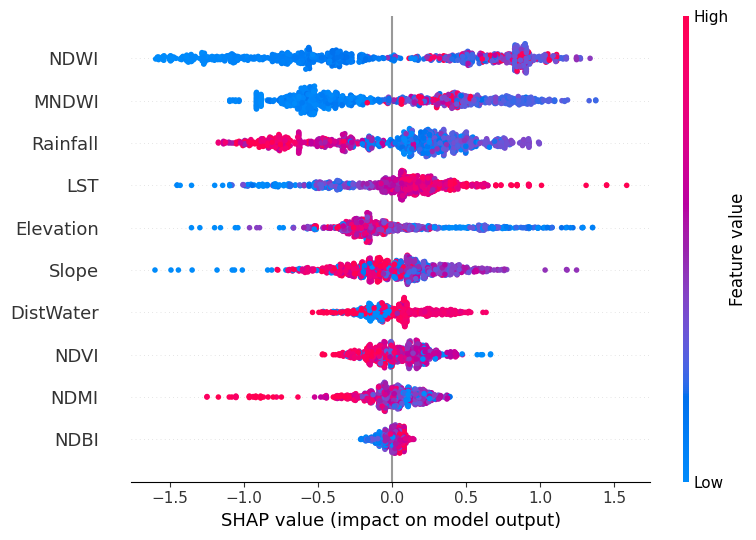

In [ ]:
# ============================================================
# SHAP - RANDOM FOREST (ALL VARIABLES)
# ============================================================

import shap

rf_all = all_estimators["Random Forest"]

preprocessor = rf_all.named_steps["preprocessor"]
rf_model = rf_all.named_steps["model"]

X_sample = data[features].sample(
    min(1000, len(data)),
    random_state=42
)

X_processed = preprocessor.transform(X_sample)

explainer = shap.TreeExplainer(rf_model)

shap_values = explainer.shap_values(X_processed)

shap.summary_plot(
    shap_values,
    X_processed,
    feature_names=features
)
# ============================================================
# SHAP - XGBOOST (ALL VARIABLES)
# ============================================================

xgb_all = all_estimators["XGBoost"]

preprocessor = xgb_all.named_steps["preprocessor"]
xgb_model = xgb_all.named_steps["model"]

X_sample = data[features].sample(
    min(1000, len(data)),
    random_state=42
)

X_processed = preprocessor.transform(X_sample)

explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_processed)

shap.summary_plot(
    shap_values,
    X_processed,
    feature_names=features
)

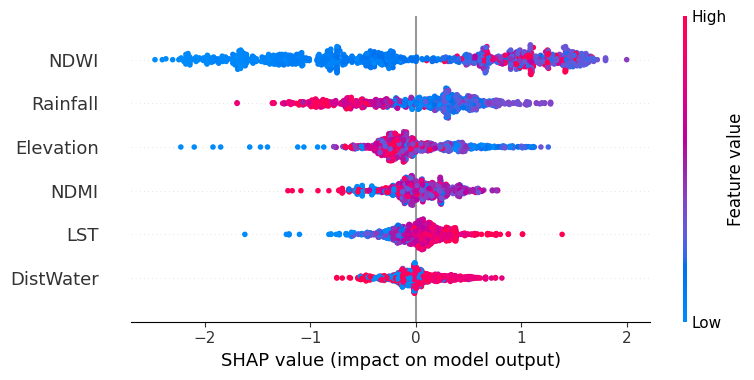

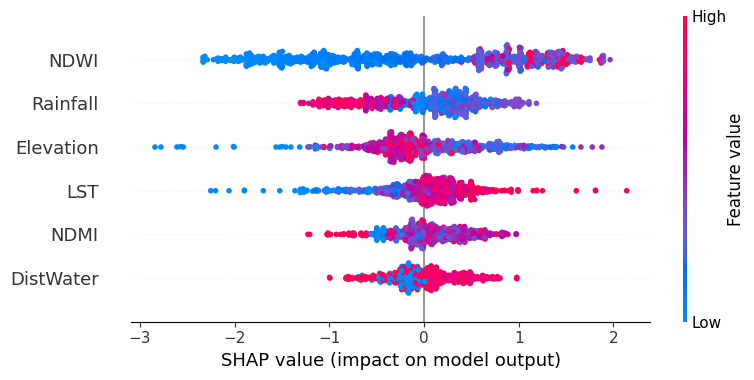

In [ ]:
# ============================================================
# SHAP - RANDOM FOREST (REDUCED VARIABLES)
# ============================================================

rf_red = reduced_estimators["Random Forest"]

preprocessor = rf_red.named_steps["preprocessor"]
rf_model = rf_red.named_steps["model"]

X_sample = data[reduced_features].sample(
    min(1000, len(data)),
    random_state=42
)

X_processed = preprocessor.transform(X_sample)

explainer = shap.TreeExplainer(rf_model)

shap_values = explainer.shap_values(X_processed)

shap.summary_plot(
    shap_values,
    X_processed,
    feature_names=reduced_features
)
# ============================================================
# SHAP - XGBOOST (REDUCED VARIABLES)
# ============================================================

xgb_red = reduced_estimators["XGBoost"]

preprocessor = xgb_red.named_steps["preprocessor"]
xgb_model = xgb_red.named_steps["model"]

X_sample = data[reduced_features].sample(
    min(1000, len(data)),
    random_state=42
)

X_processed = preprocessor.transform(X_sample)

explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_processed)

shap.summary_plot(
    shap_values,
    X_processed,
    feature_names=reduced_features
)

In [ ]:
# ============================================================
# SPATIAL CROSS-VALIDATION:
# ALL VARIABLES VS REDUCED VARIABLES
# USING ALREADY TUNED BEST PARAMETERS
# ============================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import GroupKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import make_scorer, r2_score, mean_squared_error, mean_absolute_error

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor


# ============================================================
# 1. DEFINE FEATURES AND TARGET
# ============================================================

features = [
    "NDVI", "NDWI", "NDMI", "NDBI", "MNDWI",
    "LST", "Rainfall", "Elevation", "Slope", "DistWater"
]

target = "PfPR"


# ============================================================
# 2. REMOVE HIGHLY CORRELATED VARIABLES |r| > 0.7
# ============================================================

def remove_highly_correlated_features(df, features, target, threshold=0.7):
    corr_matrix = df[features].corr().abs()
    target_corr = df[features + [target]].corr()[target].abs()

    remove_features = set()

    for i in range(len(features)):
        for j in range(i + 1, len(features)):
            f1 = features[i]
            f2 = features[j]

            if corr_matrix.loc[f1, f2] > threshold:
                if target_corr[f1] >= target_corr[f2]:
                    remove_features.add(f2)
                else:
                    remove_features.add(f1)

    selected_features = [f for f in features if f not in remove_features]

    return selected_features, list(remove_features)


reduced_features, removed_features = remove_highly_correlated_features(
    data,
    features,
    target,
    threshold=0.7
)

print("All variables:")
print(features)

print("\nRemoved highly correlated variables:")
print(removed_features)

print("\nReduced variables:")
print(reduced_features)


# ============================================================
# 3. CREATE SPATIAL GROUPS
# ============================================================

data.columns = data.columns.str.strip()

data["spatial_group"] = (
    data["longitude"].round(1).astype(str) + "_" +
    data["latitude"].round(1).astype(str)
)

groups = data["spatial_group"]

print("\nNumber of spatial groups:", groups.nunique())


# ============================================================
# 4. DEFINE SCORING METRICS
# ============================================================

def rmse_score(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


scoring = {
    "R2": make_scorer(r2_score),
    "RMSE": make_scorer(rmse_score, greater_is_better=False),
    "MAE": make_scorer(mean_absolute_error, greater_is_better=False)
}

# ============================================================
# 5. DEFINE BEST PARAMETERS FROM PREVIOUS TUNING
# ============================================================

best_params = {
    "Random Forest": {
        "n_estimators": 700,
        "max_depth": 20,
        "min_samples_split": 2,
        "min_samples_leaf": 1,
        "max_features": 0.5
    },
    "XGBoost": {
        "n_estimators": 700,
        "max_depth": 5,
        "learning_rate": 0.1,
        "subsample": 1.0,
        "colsample_bytree": 0.7,
        "reg_lambda": 5,
        "reg_alpha": 1
    },
    "SVR": {
        "kernel": "rbf",
        "C": 100,
        "gamma": "auto",
        "epsilon": 0.2
    },
    "MLP": {
        "hidden_layer_sizes": (128, 64),
        "activation": "relu",
        "alpha": 0.01,
        "learning_rate_init": 0.001
    }
}

# ============================================================
# 6. FUNCTION TO BUILD MODELS USING BEST PARAMETERS
# ============================================================

def build_models(selected_features):

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), selected_features)
        ],
        remainder="drop"
    )

    models = {
        "Random Forest": Pipeline([
            ("preprocessor", preprocessor),
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestRegressor(
                n_estimators=best_params["Random Forest"]["n_estimators"],
                max_depth=best_params["Random Forest"]["max_depth"],
                min_samples_split=best_params["Random Forest"]["min_samples_split"],
                min_samples_leaf=best_params["Random Forest"]["min_samples_leaf"],
                max_features=best_params["Random Forest"]["max_features"],
                random_state=42,
                n_jobs=-1
            ))
        ]),

        "XGBoost": Pipeline([
            ("preprocessor", preprocessor),
            ("imputer", SimpleImputer(strategy="median")),
            ("model", XGBRegressor(
                objective="reg:squarederror",
                n_estimators=best_params["XGBoost"]["n_estimators"],
                max_depth=best_params["XGBoost"]["max_depth"],
                learning_rate=best_params["XGBoost"]["learning_rate"],
                subsample=best_params["XGBoost"]["subsample"],
                colsample_bytree=best_params["XGBoost"]["colsample_bytree"],
                reg_lambda=best_params["XGBoost"]["reg_lambda"],
                reg_alpha=best_params["XGBoost"]["reg_alpha"],
                random_state=42,
                n_jobs=-1
            ))
        ]),

        "SVR": Pipeline([
            ("preprocessor", preprocessor),
            ("imputer", SimpleImputer(strategy="median")),
            ("model", SVR(
                kernel=best_params["SVR"]["kernel"],
                C=best_params["SVR"]["C"],
                gamma=best_params["SVR"]["gamma"],
                epsilon=best_params["SVR"]["epsilon"]
            ))
        ]),

        "MLP": Pipeline([
            ("preprocessor", preprocessor),
            ("imputer", SimpleImputer(strategy="median")),
            ("model", MLPRegressor(
                hidden_layer_sizes=best_params["MLP"]["hidden_layer_sizes"],
                activation=best_params["MLP"]["activation"],
                alpha=best_params["MLP"]["alpha"],
                learning_rate_init=best_params["MLP"]["learning_rate_init"],
                max_iter=1000,
                random_state=42
            ))
        ])
    }

    return models


# ============================================================
# 7. FUNCTION TO RUN SPATIAL CV FOR ONE FEATURE SET
# ============================================================

def run_spatial_cv_for_feature_set(data, selected_features, target, feature_set_name):

    X = data[selected_features].copy()
    y = data[target].copy()
    groups = data["spatial_group"]

    models = build_models(selected_features)

    gkf = GroupKFold(n_splits=5)

    results = []

    print("\n================================================")
    print(f"SPATIAL CROSS-VALIDATION: {feature_set_name}")
    print("================================================")

    for model_name, model in models.items():

        print(f"\nRunning spatial CV for {model_name} using {feature_set_name}...")

        cv_result = cross_validate(
            model,
            X,
            y,
            groups=groups,
            cv=gkf,
            scoring=scoring,
            return_train_score=False,
            n_jobs=-1
        )

        r2_scores = cv_result["test_R2"]
        rmse_scores = -cv_result["test_RMSE"]
        mae_scores = -cv_result["test_MAE"]

        result = {
            "Feature_Set": feature_set_name,
            "Model": model_name,
            "Mean_R2": np.mean(r2_scores),
            "Std_R2": np.std(r2_scores),
            "Mean_RMSE": np.mean(rmse_scores),
            "Std_RMSE": np.std(rmse_scores),
            "Mean_MAE": np.mean(mae_scores),
            "Std_MAE": np.std(mae_scores)
        }

        results.append(result)

        print("R2 folds:", r2_scores)
        print("RMSE folds:", rmse_scores)
        print("MAE folds:", mae_scores)
        print("Mean R2:", result["Mean_R2"])
        print("Mean RMSE:", result["Mean_RMSE"])
        print("Mean MAE:", result["Mean_MAE"])

    return results


# ============================================================
# 8. RUN SPATIAL CV FOR ALL VARIABLES
# ============================================================

spatial_all_results = run_spatial_cv_for_feature_set(
    data=data,
    selected_features=features,
    target=target,
    feature_set_name="All Variables"
)


# ============================================================
# 9. RUN SPATIAL CV FOR REDUCED VARIABLES
# ============================================================

spatial_reduced_results = run_spatial_cv_for_feature_set(
    data=data,
    selected_features=reduced_features,
    target=target,
    feature_set_name="Reduced Variables"
)


# ============================================================
# 10. COMBINE RESULTS
# ============================================================

spatial_cv_df = pd.DataFrame(
    spatial_all_results + spatial_reduced_results
)

spatial_cv_df = spatial_cv_df.sort_values(
    by="Mean_R2",
    ascending=False
).reset_index(drop=True)

print("\nFinal Spatial Cross-Validation Results:")
print(spatial_cv_df)


# ============================================================
# 11. SAVE RESULTS
# ============================================================

spatial_cv_df.to_csv(
    "/content/spatial_cross_validation_all_vs_reduced_features.csv",
    index=False
)

print("\nSaved as:")
print("/content/spatial_cross_validation_all_vs_reduced_features.csv")


# ============================================================
# 12. BEST SPATIAL CV MODEL
# ============================================================

best_spatial_model = spatial_cv_df.iloc[0]

print("\nBest model based on spatial cross-validation:")
print(best_spatial_model)

All variables:
['NDVI', 'NDWI', 'NDMI', 'NDBI', 'MNDWI', 'LST', 'Rainfall', 'Elevation', 'Slope', 'DistWater']

Removed highly correlated variables:
['NDVI', 'NDBI', 'MNDWI', 'Slope']

Reduced variables:
['NDWI', 'NDMI', 'LST', 'Rainfall', 'Elevation', 'DistWater']

Number of spatial groups: 50

SPATIAL CROSS-VALIDATION: All Variables

Running spatial CV for Random Forest using All Variables...
R2 folds: [0.61737263 0.57214484 0.60739034 0.47367327 0.45293976]
RMSE folds: [1.11373266 1.45748341 1.43107914 1.95086912 1.24797039]
MAE folds: [0.77080011 1.14515344 1.05467406 1.32261807 0.93685034]
Mean R2: 0.5447041671754013
Mean RMSE: 1.4402269434851889
Mean MAE: 1.0460192045743493

Running spatial CV for XGBoost using All Variables...
R2 folds: [0.60250574 0.29111054 0.63203193 0.48255781 0.31301665]
RMSE folds: [1.13516337 1.87605035 1.38544161 1.93433344 1.39849144]
MAE folds: [0.80019929 1.4630372  1.01778226 1.3216466  1.03316205]
Mean R2: 0.46424453477530137
Mean RMSE: 1.5458960414

In [ ]:
# ============================================================
# SPATIAL 80/20 SPLIT + SPATIAL CV
# ALL VARIABLES VS REDUCED VARIABLES
# ============================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import GroupShuffleSplit, GroupKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor


# ============================================================
# 1. DEFINE FEATURES AND TARGET
# ============================================================

features = [
    "NDVI", "NDWI", "NDMI", "NDBI", "MNDWI",
    "LST", "Rainfall", "Elevation", "Slope", "DistWater"
]

target = "PfPR"

data.columns = data.columns.str.strip()


# ============================================================
# 2. REMOVE HIGHLY CORRELATED VARIABLES |r| > 0.7
# ============================================================

def remove_highly_correlated_features(df, features, target, threshold=0.7):
    corr_matrix = df[features].corr().abs()
    target_corr = df[features + [target]].corr()[target].abs()

    remove_features = set()

    for i in range(len(features)):
        for j in range(i + 1, len(features)):
            f1 = features[i]
            f2 = features[j]

            if corr_matrix.loc[f1, f2] > threshold:
                if target_corr[f1] >= target_corr[f2]:
                    remove_features.add(f2)
                else:
                    remove_features.add(f1)

    selected_features = [f for f in features if f not in remove_features]

    return selected_features, list(remove_features)


reduced_features, removed_features = remove_highly_correlated_features(
    data,
    features,
    target,
    threshold=0.7
)

print("All variables:", features)
print("Removed variables:", removed_features)
print("Reduced variables:", reduced_features)


# ============================================================
# 3. CREATE SPATIAL BLOCKS
# ============================================================

data["spatial_block"] = (
    data["longitude"].round(1).astype(str) + "_" +
    data["latitude"].round(1).astype(str)
)

print("Total spatial blocks:", data["spatial_block"].nunique())


# ============================================================
# 4. SPATIAL 80/20 SPLIT BY BLOCKS
# ============================================================

groups_all = data["spatial_block"]

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(data, data[target], groups=groups_all)
)

train_data = data.iloc[train_idx].copy()
test_data = data.iloc[test_idx].copy()

print("\nTraining data shape:", train_data.shape)
print("Withheld spatial test data shape:", test_data.shape)

print("Training spatial blocks:", train_data["spatial_block"].nunique())
print("Testing spatial blocks:", test_data["spatial_block"].nunique())

overlap_blocks = set(train_data["spatial_block"]).intersection(
    set(test_data["spatial_block"])
)

print("Number of overlapping spatial blocks:", len(overlap_blocks))


# ============================================================
# 5. BEST PARAMETERS FROM RANDOMIZED SEARCH
# ============================================================

best_params = {
    "Random Forest": {
        "n_estimators": 700,
        "max_depth": 20,
        "min_samples_split": 2,
        "min_samples_leaf": 1,
        "max_features": 0.5
    },

    "XGBoost": {
        "n_estimators": 700,
        "max_depth": 5,
        "learning_rate": 0.1,
        "subsample": 1.0,
        "colsample_bytree": 0.7,
        "reg_lambda": 5,
        "reg_alpha": 1
    },

    "SVR": {
        "kernel": "rbf",
        "C": 100,
        "gamma": "auto",
        "epsilon": 0.2
    },

    "MLP": {
        "hidden_layer_sizes": (128, 64),
        "activation": "relu",
        "alpha": 0.01,
        "learning_rate_init": 0.001
    }
}


# ============================================================
# 6. BUILD MODELS
# ============================================================

def build_models(selected_features):

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), selected_features)
        ],
        remainder="drop"
    )

    models = {
        "Random Forest": Pipeline([
            ("preprocessor", preprocessor),
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestRegressor(
                n_estimators=best_params["Random Forest"]["n_estimators"],
                max_depth=best_params["Random Forest"]["max_depth"],
                min_samples_split=best_params["Random Forest"]["min_samples_split"],
                min_samples_leaf=best_params["Random Forest"]["min_samples_leaf"],
                max_features=best_params["Random Forest"]["max_features"],
                random_state=42,
                n_jobs=-1
            ))
        ]),

        "XGBoost": Pipeline([
            ("preprocessor", preprocessor),
            ("imputer", SimpleImputer(strategy="median")),
            ("model", XGBRegressor(
                objective="reg:squarederror",
                n_estimators=best_params["XGBoost"]["n_estimators"],
                max_depth=best_params["XGBoost"]["max_depth"],
                learning_rate=best_params["XGBoost"]["learning_rate"],
                subsample=best_params["XGBoost"]["subsample"],
                colsample_bytree=best_params["XGBoost"]["colsample_bytree"],
                reg_lambda=best_params["XGBoost"]["reg_lambda"],
                reg_alpha=best_params["XGBoost"]["reg_alpha"],
                random_state=42,
                n_jobs=-1
            ))
        ]),

        "SVR": Pipeline([
            ("preprocessor", preprocessor),
            ("imputer", SimpleImputer(strategy="median")),
            ("model", SVR(
                kernel=best_params["SVR"]["kernel"],
                C=best_params["SVR"]["C"],
                gamma=best_params["SVR"]["gamma"],
                epsilon=best_params["SVR"]["epsilon"]
            ))
        ]),

        "MLP": Pipeline([
            ("preprocessor", preprocessor),
            ("imputer", SimpleImputer(strategy="median")),
            ("model", MLPRegressor(
                hidden_layer_sizes=best_params["MLP"]["hidden_layer_sizes"],
                activation=best_params["MLP"]["activation"],
                alpha=best_params["MLP"]["alpha"],
                learning_rate_init=best_params["MLP"]["learning_rate_init"],
                max_iter=1000,
                random_state=42
            ))
        ])
    }

    return models


# ============================================================
# 7. EVALUATION FUNCTIONS
# ============================================================

def evaluate_model(model_name, feature_set, y_true, y_pred):
    return {
        "Feature_Set": feature_set,
        "Model": model_name,
        "R2": r2_score(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred)
    }


def spatial_cv_report(model, X, y, groups, cv):
    scoring = {
        "r2": "r2",
        "neg_rmse": "neg_root_mean_squared_error",
        "neg_mae": "neg_mean_absolute_error"
    }

    scores = cross_validate(
        model,
        X,
        y,
        groups=groups,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    fold_report = pd.DataFrame({
        "Fold": np.arange(1, len(scores["test_r2"]) + 1),
        "R2": scores["test_r2"],
        "RMSE": -scores["test_neg_rmse"],
        "MAE": -scores["test_neg_mae"]
    })

    summary = {
        "Mean_R2": fold_report["R2"].mean(),
        "Std_R2": fold_report["R2"].std(),
        "Mean_RMSE": fold_report["RMSE"].mean(),
        "Std_RMSE": fold_report["RMSE"].std(),
        "Mean_MAE": fold_report["MAE"].mean(),
        "Std_MAE": fold_report["MAE"].std()
    }

    return fold_report, summary


# ============================================================
# 8. RUN SPATIAL VALIDATION FOR ONE FEATURE SET
# ============================================================

def run_spatial_validation(train_data, test_data, selected_features, target, feature_set_name):

    X_train = train_data[selected_features].copy()
    y_train = train_data[target].copy()
    groups_train = train_data["spatial_block"]

    X_test = test_data[selected_features].copy()
    y_test = test_data[target].copy()

    n_groups = groups_train.nunique()
    n_splits = min(5, n_groups)

    if n_splits < 2:
        raise ValueError("Not enough spatial blocks for spatial cross-validation.")

    spatial_cv = GroupKFold(n_splits=n_splits)

    models = build_models(selected_features)

    cv_summary_results = []
    withheld_test_results = []
    fold_reports = {}

    for model_name, model in models.items():

        print("\n================================================")
        print(f"{model_name} - {feature_set_name}")
        print("================================================")

        # Spatial cross-validation inside training set
        fold_report, cv_summary = spatial_cv_report(
            model,
            X_train,
            y_train,
            groups_train,
            spatial_cv
        )

        cv_summary["Feature_Set"] = feature_set_name
        cv_summary["Model"] = model_name

        cv_summary_results.append(cv_summary)
        fold_reports[f"{feature_set_name}_{model_name}"] = fold_report

        print("\nSpatial CV Fold Results:")
        print(fold_report)

        print("\nSpatial CV Summary:")
        print(cv_summary)

        # Fit on full spatial training data
        model.fit(X_train, y_train)

        # Evaluate on withheld spatial 20% test data
        y_pred = model.predict(X_test)

        test_result = evaluate_model(
            model_name,
            feature_set_name,
            y_test,
            y_pred
        )

        withheld_test_results.append(test_result)

        print("\nWithheld Spatial 20% Test Result:")
        print(test_result)

    return cv_summary_results, withheld_test_results, fold_reports


# ============================================================
# 9. RUN FOR ALL VARIABLES
# ============================================================

cv_all, test_all, folds_all = run_spatial_validation(
    train_data=train_data,
    test_data=test_data,
    selected_features=features,
    target=target,
    feature_set_name="All Variables"
)


# ============================================================
# 10. RUN FOR REDUCED VARIABLES
# ============================================================

cv_reduced, test_reduced, folds_reduced = run_spatial_validation(
    train_data=train_data,
    test_data=test_data,
    selected_features=reduced_features,
    target=target,
    feature_set_name="Reduced Variables"
)


# ============================================================
# 11. COMBINE RESULTS
# ============================================================

spatial_cv_summary_df = pd.DataFrame(cv_all + cv_reduced)
spatial_test_df = pd.DataFrame(test_all + test_reduced)

spatial_cv_summary_df = spatial_cv_summary_df[
    [
        "Feature_Set", "Model",
        "Mean_R2", "Std_R2",
        "Mean_RMSE", "Std_RMSE",
        "Mean_MAE", "Std_MAE"
    ]
].sort_values(by="Mean_R2", ascending=False).reset_index(drop=True)

spatial_test_df = spatial_test_df[
    ["Feature_Set", "Model", "R2", "RMSE", "MAE"]
].sort_values(by="R2", ascending=False).reset_index(drop=True)

print("\n================================================")
print("SPATIAL CROSS-VALIDATION SUMMARY")
print("================================================")
print(spatial_cv_summary_df)

print("\n================================================")
print("WITHHELD SPATIAL 80/20 TEST RESULTS")
print("================================================")
print(spatial_test_df)


# ============================================================
# 12. SAVE RESULTS
# ============================================================

spatial_cv_summary_df.to_csv(
    "/content/spatial_cv_summary_all_vs_reduced.csv",
    index=False
)

spatial_test_df.to_csv(
    "/content/spatial_80_20_test_results_all_vs_reduced.csv",
    index=False
)

print("\nSaved:")
print("/content/spatial_cv_summary_all_vs_reduced.csv")
print("/content/spatial_80_20_test_results_all_vs_reduced.csv")


# ============================================================
# 13. BEST MODEL BASED ON WITHHELD SPATIAL TEST
# ============================================================

best_spatial_test_model = spatial_test_df.iloc[0]

print("\nBest model based on withheld spatial 80/20 test:")
print(best_spatial_test_model)

All variables: ['NDVI', 'NDWI', 'NDMI', 'NDBI', 'MNDWI', 'LST', 'Rainfall', 'Elevation', 'Slope', 'DistWater']
Removed variables: ['NDVI', 'NDBI', 'MNDWI', 'Slope']
Reduced variables: ['NDWI', 'NDMI', 'LST', 'Rainfall', 'Elevation', 'DistWater']
Total spatial blocks: 50

Training data shape: (1055, 16)
Withheld spatial test data shape: (410, 16)
Training spatial blocks: 40
Testing spatial blocks: 10
Number of overlapping spatial blocks: 0

Random Forest - All Variables

Spatial CV Fold Results:
   Fold        R2      RMSE       MAE
0     1  0.560480  1.755927  1.379240
1     2  0.361215  1.589131  1.213276
2     3  0.772913  1.213767  0.856417
3     4  0.424065  1.731616  1.072792
4     5  0.170789  1.558052  1.241223

Spatial CV Summary:
{'Mean_R2': np.float64(0.45789249895128387), 'Std_R2': 0.22510070495072967, 'Mean_RMSE': np.float64(1.569698601625706), 'Std_RMSE': 0.21685202924980046, 'Mean_MAE': np.float64(1.1525895247740743), 'Std_MAE': 0.19811316159678638, 'Feature_Set': 'All Va

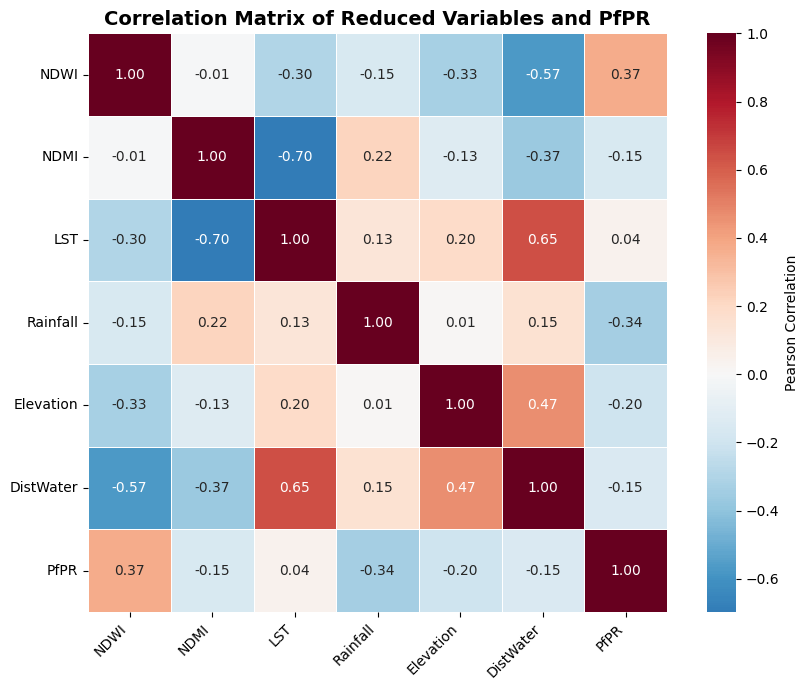

In [ ]:
# ============================================================
# CORRELATION MATRIX - REDUCED VARIABLES + PfPR
# ============================================================

corr_reduced_pfpr = data[reduced_features + [target]].corr()

plt.figure(figsize=(9,7))

sns.heatmap(
    corr_reduced_pfpr,
    annot=True,
    cmap="RdBu_r",
    center=0,
    fmt=".2f",
    linewidths=0.5,
    square=True,
    cbar_kws={"label":"Pearson Correlation"}
)

plt.title(
    "Correlation Matrix of Reduced Variables and PfPR",
    fontsize=14,
    fontweight="bold"
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()